# Project Machine Learning for IOTs
Author: Yingshuo Xi, Ali Jahangiri

# 1 Data Loading

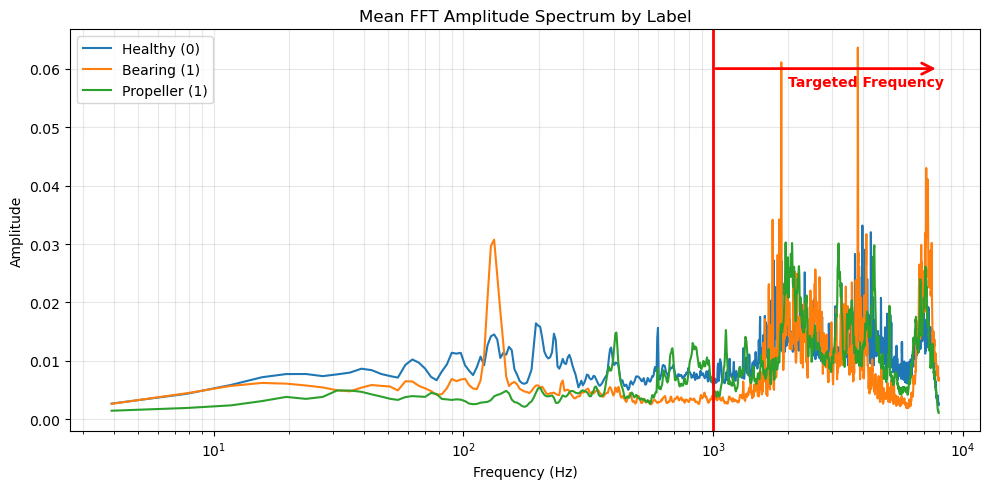

In [1]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt

name = [ # Healthy
        # "Data/Healthy/M1/1400.wav",        # Not included due to different sampling rate
        "Data/Healthy/M1/1450.wav", "Data/Healthy/M1/1550.wav", "Data/Healthy/M1/1650.wav",
        "Data/Healthy/M1/1750.wav", "Data/Healthy/M1/1850.wav", "Data/Healthy/M1/1950.wav", "Data/Healthy/M1/2000.wav", 
        
        "Data/Healthy/M2/1400.wav", "Data/Healthy/M2/1450.wav", "Data/Healthy/M2/1550.wav", "Data/Healthy/M2/1650.wav",
        "Data/Healthy/M2/1750.wav", "Data/Healthy/M2/1850.wav", "Data/Healthy/M2/1950.wav", "Data/Healthy/M2/2000.wav", 

        "Data/Healthy/M3/1450.wav", "Data/Healthy/M3/1550.wav", "Data/Healthy/M3/1650.wav",
        "Data/Healthy/M3/1750.wav", "Data/Healthy/M3/1850.wav", "Data/Healthy/M3/1950.wav", 

        # Bearing
        "Data/Bearing/M4/1700.wav", "Data/Bearing/M4/1750.wav", "Data/Bearing/M4/1800.wav", "Data/Bearing/M4/1850.wav", 
        "Data/Bearing/M4/1900.wav", "Data/Bearing/M4/1950.wav", "Data/Bearing/M4/2000.wav",

        # Propeller
        "Data/Propeller/M1/1400.wav", "Data/Propeller/M1/1450.wav", "Data/Propeller/M1/1550.wav", "Data/Propeller/M1/1650.wav", 
        "Data/Propeller/M1/1750.wav", "Data/Propeller/M1/1850.wav",

        "Data/Propeller/M2/1400.wav", "Data/Propeller/M2/1450.wav", "Data/Propeller/M2/1550.wav", "Data/Propeller/M2/1650.wav", 
        "Data/Propeller/M2/1750.wav", "Data/Propeller/M2/1850.wav", "Data/Propeller/M2/1950.wav", "Data/Propeller/M2/2000.wav"
       ]
labels = [  # Healthy
            0, 0, 0,
            0, 0, 0, 0, 
            
            0, 0, 0, 0,
            0, 0, 0, 0, 
    
            0, 0, 0,
            0, 0, 0,

            # Bearing
            1, 1, 1, 1, 
            1, 1, 1,

            # Propeller
            2, 2, 2, 2,
            2, 2,
    
            2, 2, 2, 2,
            2, 2, 2, 2
           ]

# 0 = Train, 1 = Validation, 1 = Test, 2 = Not used
train_val_test_mark = [  # Healthy
            0, 1, 2,
            0, 3, 3, 3, 
            
            0, 1, 2, 0,
            0, 1, 2, 0, 
    
            0, 1, 2,
            0, 3, 3,

            # Bearing
            0, 1, 2, 0, 
            0, 1, 2,

            # Propeller
            0, 1, 2, 0,
            3, 3,
    
            0, 1, 2, 0,
            3, 3, 3, 3
           ]

def mean_amp_spectrum_by_segments(x, fs, n_fft=4096):
    x = x.astype(np.float64)
    x = x - np.mean(x)

    w = np.hanning(n_fft)

    # Segmentation
    n = len(x)
    if n < n_fft:
        x = np.pad(x, (0, n_fft - n))
        n = len(x)

    starts = np.arange(0, n - n_fft + 1, n_fft // 2)
    amps = []

    for s in starts:
        frame = x[s:s+n_fft] * w
        X = np.fft.rfft(frame, n=n_fft)

        # Amplitude Spectrum
        A = np.abs(X) / (np.sum(w) + 1e-12)
        amps.append(A)

    A_mean = np.mean(np.stack(amps, axis=0), axis=0)
    f = np.fft.rfftfreq(n_fft, d=1.0/fs)
    return f, A_mean

def plot_mean_fft_by_label(names, labels, n_fft=4096):
    spec_by_label = {0: [], 1: [], 2: []}
    f_ref = None
    fs_ref = None

    for path, lab in zip(names, labels):
        fs, data = wavfile.read(path)

        if data.ndim == 2:
            data = data.mean(axis=1)

        # Data Normalization
        eps = 1e-12
        data = data.astype(np.float64)
        data = (data - data.mean()) / (data.std() + eps)

        # Check the sampling rate
        if fs_ref is None:
            fs_ref = fs
        elif fs != fs_ref:
            raise ValueError(f"Sampling rate is difference")

        f, A_mean = mean_amp_spectrum_by_segments(data, fs, n_fft=n_fft)
        if f_ref is None:
            f_ref = f

        spec_by_label[int(lab)].append(A_mean)

    # Average by label
    A0 = np.mean(np.stack(spec_by_label[0], axis=0), axis=0) if len(spec_by_label[0]) else None
    A1 = np.mean(np.stack(spec_by_label[1], axis=0), axis=0) if len(spec_by_label[1]) else None
    A2 = np.mean(np.stack(spec_by_label[2], axis=0), axis=0) if len(spec_by_label[2]) else None

    plt.figure(figsize=(10, 5))
    if A0 is not None:
        plt.semilogx(f_ref[1:], A0[1:], label="Healthy (0)")
    if A1 is not None:
        plt.semilogx(f_ref[1:], A1[1:], label="Bearing (1)")
    if A2 is not None:
        plt.semilogx(f_ref[1:], A2[1:], label="Propeller (1)")

    plt.title("Mean FFT Amplitude Spectrum by Label")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()

    return fs

sampling_rate = plot_mean_fft_by_label(name, labels)
plt.axvline(x=1e3, color='red', linewidth=2)
plt.annotate('', xy=(8e3, 0.06), xytext=(1e3, 0.06), arrowprops=dict(arrowstyle='->', color='red', linewidth=2, mutation_scale=20))
plt.text(2e3, 0.057, "Targeted Frequency", color='red', fontsize=10, fontweight="bold")
plt.show()

In [2]:
import math

def min_samples_for_frequency(f0, sample_rate, K=5):
    L = K * sample_rate / f0
    return math.ceil(L)

f0 = 1000
K = 5

L = min_samples_for_frequency(f0, sampling_rate, K)
print(f"To capture enough cycles ({K}) of the frequency ({f0} Hz) based on the sampling rate ({sampling_rate} Hz), \033[1mthe minimal data points per sample: {L}\033[0m.")

To capture enough cycles (5) of the frequency (1000 Hz) based on the sampling rate (16000 Hz), the minimal data points per sample: 80.


In [3]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt

segment_length = 80
downsampling_rate = 10
labels_value = (np.array(labels) < 1).astype(int)

def build_dataset(name, labels_value, mark, target_mark, mean_train = None, std_train = None):
    all_segments = []
    all_labels = []

    if not set(labels_value).issubset({0,1}):
        raise ValueError("Error: labels_value must contain only 0 and 1.")

    for i in range(len(name)):
        if mark[i] != target_mark:
            continue
            
        sample_rate, data = wavfile.read(name[i])
        if len(data.shape) == 2:
            data = data.mean(axis=1)
        
        # Data Self-Normalization
        eps = 1e-12
        mean = data.mean()
        std  = data.std()
        data = (data - mean) / (std + eps)

        # # Down Sampling
        # num_ds = len(data) // downsampling_rate
        # data = data[:num_ds * downsampling_rate]
        # data = data.reshape(-1, downsampling_rate)
        # data = data.mean(axis = 1)

        # Cut into pieces
        num_segments = len(data) // segment_length
        data = data[:num_segments * segment_length]
        segments = data.reshape(num_segments, segment_length)
        # print(name[i], segments.shape)
    
        labels = np.full(num_segments, labels_value[i], dtype=np.uint8)
        all_segments.append(segments)
        all_labels.append(labels)

    all_segments = np.vstack(all_segments)
    all_labels = np.concatenate(all_labels)
    print("Before shuffle:", all_segments.shape, all_labels.shape)
    
    indices = np.random.permutation(len(all_segments))
    all_segments = all_segments[indices]
    all_labels = all_labels[indices]
    print("After shuffle:", all_segments.shape, all_labels.shape)

    print(f"label(0) = {len(all_labels) - np.sum(all_labels)} ({(1 - np.sum(all_labels)/len(all_labels))*100:.2f}%), label(1) = {np.sum(all_labels)} ({(np.sum(all_labels)/len(all_labels))*100:.2f}%)")

    # # Normalization
    # eps = 1e-12
    # if target_mark == 0:  # Train
    #     mean_train = all_segments.mean(axis=0)
    #     std_train  = all_segments.std(axis=0)
    #     all_segments = (all_segments - mean_train) / (std_train + eps)
    # if target_mark == 1:  # Test
    #     all_segments = (all_segments - mean_train) / (std_train + eps)

    return all_segments, all_labels, mean_train, std_train

In [4]:
print("TRAIN: ")
train_X, train_y, mean_train, std_train = build_dataset(name, labels_value, train_val_test_mark, 0)
print("\nVALIDATION: ")
val_X, val_y, _, _ = build_dataset(name, labels_value, train_val_test_mark, 1, mean_train, std_train)
print("\nTEST: ")
test_X, test_y, _, _ = build_dataset(name, labels_value, train_val_test_mark, 2, mean_train, std_train)
# < 65536 (2^16), Use 2-byte-sequence number 

TRAIN: 
Before shuffle: (30825, 80) (30825,)
After shuffle: (30825, 80) (30825,)
label(0) = 14425 (46.80%), label(1) = 16400 (53.20%)

VALIDATION: 
Before shuffle: (16472, 80) (16472,)
After shuffle: (16472, 80) (16472,)
label(0) = 8236 (50.00%), label(1) = 8236 (50.00%)

TEST: 
Before shuffle: (16392, 80) (16392,)
After shuffle: (16392, 80) (16392,)
label(0) = 8186 (49.94%), label(1) = 8206 (50.06%)


# 3 PC & STM32

Here is the code for PC and STM32. You can first start either PC or STM32. The order does not matter.

**The code below is universal for both Backpropagation and Forward-Forward.**

You can view detailed messages by setting the parameter **show_detaied_print** to 1.

Switches of STM32:
- SW1: End Python code, Set STM32 to Idle
- SW2: Set STM32 to Idle
- SW3: Resume from Idle.

In [9]:
import serial
import struct
import time

CODE_START_OF_FRAME_0 = b"\xAA"
CODE_START_OF_FRAME_1 = b"\x55"
CODE_START_OF_FRAME = CODE_START_OF_FRAME_0 + CODE_START_OF_FRAME_1

CODE_REQUEST_DATA = 0x01
CODE_DATA = 0x02
CODE_ACKNOWLEDGEMENT = 0x03
CODE_FINISH = 0x04
CODE_END = 0x05
CODE_RESULTS_TRAIN = 0x06
CODE_REQUEST_VAL = 0x07
CODE_VAL_ACC = 0x08
CODE_REQUEST_TEST = 0x09
CODE_TEST_PRED = 0x0A

show_detaied_print = 0

correct_count = 0
window_correct = 0
window_total = 0
window_loss_sum = 0.0
log_interval = 5000
test_predictions = []


def crc_check(data: bytes) -> int:
    crc = 0xFFFF
    for d in data:
        crc ^= (d << 8)
        for _ in range(8):
            if (crc & 0x8000):
                crc = ((crc << 1) ^ 0x1021) & 0xFFFF
            else:
                crc = (crc << 1) & 0xFFFF
    return crc


def pack_frame(data_type: int, message_sequence: int, data: bytes) -> bytes:
    message_sequence &= 0xFFFF
    length = len(data) & 0xFFFF
    message_bytes = struct.pack("<BHH", data_type, message_sequence, length) + data
    crc = crc_check(message_bytes)
    crc_bytes = struct.pack("<H", crc)
    return CODE_START_OF_FRAME + message_bytes + crc_bytes


def read_n_bytes(ser: serial.Serial, n: int):
    buf_all = bytearray()
    while len(buf_all) < n:
        buf = ser.read(n - len(buf_all))
        if not buf:
            return None
        buf_all += buf
    return bytes(buf_all)


def read_frame(ser: serial.Serial):
    while True:
        start_of_frame_0 = ser.read(1)
        if not start_of_frame_0:
            return None
        if start_of_frame_0 == CODE_START_OF_FRAME_0:
            start_of_frame_1 = ser.read(1)
            if not start_of_frame_1:
                return None
            if start_of_frame_1 == CODE_START_OF_FRAME_1:
                break

    header = read_n_bytes(ser, 1 + 2 + 2)
    if header is None:
        return None

    data_type = header[0]
    message_sequence, length = struct.unpack("<HH", header[1:])

    data = read_n_bytes(ser, length)
    if data is None:
        return None

    crc_bytes = read_n_bytes(ser, 2)
    if crc_bytes is None:
        return None

    crc_recv = struct.unpack("<H", crc_bytes)[0]
    body = struct.pack("<BHH", data_type, message_sequence, length) + data

    if crc_check(body) != crc_recv:
        print("CRC mismatch, frame dropped")
        return None

    return data_type, message_sequence, data


def handle_results_frame(seq, data):
    global correct_count, window_correct, window_total, window_loss_sum

    if len(data) < 9:
        print(f"Invalid RESULTS frame at seq={seq}, len={len(data)}")
        return

    loss = struct.unpack("<f", data[0:4])[0]
    probability = struct.unpack("<f", data[4:8])[0]
    correct = int(data[8])

    correct_count += correct
    window_correct += correct
    window_total += 1
    window_loss_sum += loss

    if show_detaied_print:
        print(
            f"Results decoded: seq={seq}, "
            f"loss={loss:.6f}, probability={probability:.6f}, correct={correct}"
        )

    if window_total >= log_interval:
        window_acc = window_correct / window_total if window_total > 0 else 0.0
        window_loss_avg = window_loss_sum / window_total if window_total > 0 else 0.0
        print(
            f"WinAcc({window_total}): {window_acc:.4f} | "
            f"WinAvgLoss({window_total}): {window_loss_avg:.6f}"
        )
        window_correct = 0
        window_total = 0
        window_loss_sum = 0.0


def handle_test_pred_frame(seq, data, test_y):
    global test_predictions

    if len(data) < 5:
        print(f"Invalid TEST_PRED frame at seq={seq}, len={len(data)}")
        return

    probability = struct.unpack("<f", data[0:4])[0]
    pred = int(data[4])

    y_true = int(test_y[seq]) if seq < len(test_y) else None

    item = {
        "seq": int(seq),
        "y_true": y_true,
        "probability": float(probability),
        "pred": pred,
    }
    test_predictions.append(item)

    if show_detaied_print:
        print(
            f"TEST_PRED decoded: seq={seq}, "
            f"probability={probability:.6f}, pred={pred}, y_true={y_true}"
        )


def wait_for_ack(ser, expected_seq, test_y, timeout_s=2.0):
    global correct_count, window_correct, window_total, window_loss_sum

    deadline = time.time() + timeout_s

    while time.time() < deadline:
        frame = read_frame(ser)
        if frame is None:
            continue

        data_type, seq, data = frame

        if show_detaied_print:
            print(f"ACK-loop got frame: type={hex(data_type)} seq={seq} len={len(data)}")

        if data_type == CODE_END:
            print("Received END from STM32. Exit.")
            return "end"

        if data_type == CODE_RESULTS_TRAIN:
            handle_results_frame(seq, data)
            continue

        if data_type == CODE_TEST_PRED:
            handle_test_pred_frame(seq, data, test_y)
            continue

        if data_type == CODE_VAL_ACC:
            if len(data) >= 4:
                acc = struct.unpack("<f", data[:4])[0]
                print(f"STM32 inference accuracy = {acc:.6f}")

            window_correct = 0
            window_total = 0
            window_loss_sum = 0.0
            correct_count = 0
            continue

        if data_type != CODE_ACKNOWLEDGEMENT:
            continue

        if seq != expected_seq:
            continue

        status = data[0] if len(data) >= 1 else 0
        if status != 0:
            print(f"ACK error: seq={expected_seq}, status={status}")
            return "ack_error"

        return "ok"

    print(f"ACK timeout for seq={expected_seq}")
    return "timeout"


def send_dataset(port, baud, train_X, train_y, val_X, val_y, test_X, test_y):
    global correct_count, window_correct, window_total, window_loss_sum, test_predictions

    test_predictions = []

    segment_length = train_X.shape[1]

    if val_X.shape[1] != segment_length:
        raise ValueError("train_X and val_X feature dimensions do not match")

    if test_X.shape[1] != segment_length:
        raise ValueError("train_X and test_X feature dimensions do not match")

    with serial.Serial(port, baud, timeout=1.0) as ser:
        time.sleep(1)
        ser.reset_input_buffer()
        ser.reset_output_buffer()

        print("Ready. Waiting for STM32 requests...")

        last_report_time = time.time()

        while True:
            frame = read_frame(ser)

            if frame is None:
                if time.time() - last_report_time > 2:
                    print("Still waiting for requests...")
                    last_report_time = time.time()
                continue

            data_type, seq, data = frame

            if show_detaied_print:
                print(f"Main-loop got frame: type={hex(data_type)} seq={seq} len={len(data)}")

            if data_type == CODE_END:
                print("Received END from STM32. Exit.")
                test_predictions.sort(key=lambda x: x["seq"])
                return test_predictions

            if data_type == CODE_RESULTS_TRAIN:
                handle_results_frame(seq, data)
                continue

            if data_type == CODE_TEST_PRED:
                handle_test_pred_frame(seq, data, test_y)
                continue

            if data_type == CODE_VAL_ACC:
                if len(data) >= 4:
                    acc = struct.unpack("<f", data[:4])[0]
                    print(f"STM32 inference accuracy = {acc:.6f}")

                window_correct = 0
                window_total = 0
                window_loss_sum = 0.0
                correct_count = 0
                continue

            if data_type == CODE_REQUEST_DATA:
                if seq >= train_X.shape[0]:
                    ser.write(pack_frame(CODE_FINISH, seq, b""))
                    print(f"Training data finished at seq={seq}, sent CODE_FINISH")
                    continue

                data_row = train_X[seq]
                if len(data_row) != segment_length:
                    raise ValueError(
                        f"train sample {seq} length is {len(data_row)}, expected {segment_length}"
                    )

                payload = struct.pack(
                    f"<B{segment_length}f",
                    int(train_y[seq]),
                    *data_row.tolist()
                )

                ser.write(pack_frame(CODE_DATA, seq, payload))

                if show_detaied_print:
                    print(f"Sent TRAIN DATA seq={seq}")

                ack_result = wait_for_ack(ser, seq, test_y)
                if ack_result == "end":
                    test_predictions.sort(key=lambda x: x["seq"])
                    return test_predictions
                continue

            if data_type == CODE_REQUEST_VAL:
                if seq >= val_X.shape[0]:
                    ser.write(pack_frame(CODE_FINISH, seq, b""))
                    print(f"Inference data finished at seq={seq}, sent CODE_FINISH")
                    continue

                data_row = val_X[seq]
                if len(data_row) != segment_length:
                    raise ValueError(
                        f"val sample {seq} length is {len(data_row)}, expected {segment_length}"
                    )

                payload = struct.pack(
                    f"<B{segment_length}f",
                    int(val_y[seq]),
                    *data_row.tolist()
                )

                ser.write(pack_frame(CODE_DATA, seq, payload))

                if show_detaied_print:
                    print(f"Sent INFER DATA seq={seq}")

                ack_result = wait_for_ack(ser, seq, test_y)
                if ack_result == "end":
                    test_predictions.sort(key=lambda x: x["seq"])
                    return test_predictions
                continue

            if data_type == CODE_REQUEST_TEST:
                if seq >= test_X.shape[0]:
                    ser.write(pack_frame(CODE_FINISH, seq, b""))
                    print(f"Test data finished at seq={seq}, sent CODE_FINISH")
                    continue

                data_row = test_X[seq]
                if len(data_row) != segment_length:
                    raise ValueError(
                        f"test sample {seq} length is {len(data_row)}, expected {segment_length}"
                    )

                payload = struct.pack(
                    f"<B{segment_length}f",
                    int(test_y[seq]),
                    *data_row.tolist()
                )

                ser.write(pack_frame(CODE_DATA, seq, payload))

                if show_detaied_print:
                    print(f"Sent TEST DATA seq={seq}")

                ack_result = wait_for_ack(ser, seq, test_y)
                if ack_result == "end":
                    test_predictions.sort(key=lambda x: x["seq"])
                    return test_predictions
                continue

            print(f"Unexpected frame type: {hex(data_type)} seq={seq} len={len(data)}")

test_results = send_dataset(
    'COM4', 209700,
    train_X, train_y,
    val_X, val_y,
    test_X, test_y
)

Ready. Waiting for STM32 requests...
Test data finished at seq=16392, sent CODE_FINISH
STM32 inference accuracy = 0.773121
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still waiting for requests...
Still w

In [10]:
# Check the received data
seqs = [d["seq"] for d in test_results]
print(seqs[:20])

print("len =", len(seqs))
print("unique len =", len(set(seqs)))
print("duplicates =", sorted([x for x in set(seqs) if seqs.count(x) > 1]))
print("missing =", [i for i in range(min(seqs), max(seqs)+1) if i not in set(seqs)])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
len = 16392
unique len = 16392
duplicates = []
missing = []


Accuracy: 0.7731210346510493
Confusion Matrix:
 [[7293  893]
 [2826 5380]]


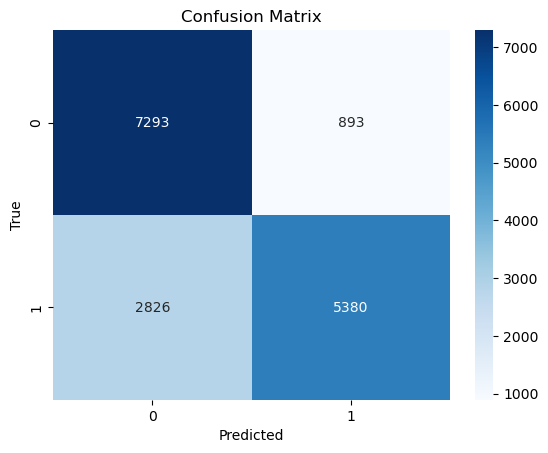

In [11]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, f1_score
import matplotlib.pyplot as plt

data = test_results

filtered = [
    d for d in data
    if d["y_true"] in [0, 1] and d["pred"] in [0, 1]
]

y_true = np.array([d["y_true"] for d in filtered])
y_pred = np.array([d["pred"] for d in filtered])
y_prob = np.array([d["probability"] for d in filtered])

acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

F1 score: 0.7431452448373507
AUC: 0.8752709666593403


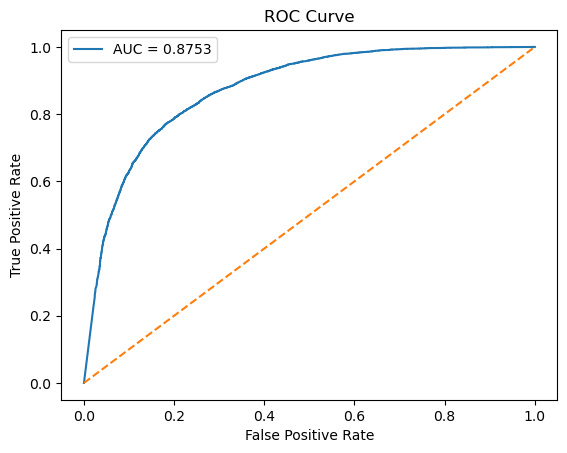

In [12]:
f1 = f1_score(y_true, y_pred)
print("F1 score:", f1)

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()